In [1]:
!python -m pip install doubtlab

     |████████████████████████████████| 23.2 MB 56.6 MB/s 
     |████████████████████████████████| 77 kB 4.7 MB/s 
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.23.2
    Uninstalling scikit-learn-0.23.2:
      Successfully uninstalled scikit-learn-0.23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.4.3 which is incompatible.
hypertools 0.7.0 requires scikit-learn!=0.22,<0.24,>=0.19.1, but you have scikit-learn 1.0.1 which is incompatible.


In [2]:
from sklearn.linear_model import LogisticRegression

from doubtlab.ensemble import DoubtEnsemble
from doubtlab.reason import CleanlabReason, ProbaReason, WrongPredictionReason
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# Doubtlab


Doubtlab provides general tricks that may help you find bad, or noisy, labels in your dataset. You can use doubtlab to check your own datasets for bad labels. Many of the methods that provided are based on the interaction between a dataset and a model trained on that dataset.

Doubtlab provides many methods for bad/noisy label detection.

### General Reasons
- **RandomReason:** assign doubt randomly, just for sure
- **OutlierReason:** assign doubt when the model declares a row an outlier

### Classification Reasons
- **ProbaReason:** assign doubt when a models' confidence-values are low
- **LongConfidenceReason:** assign doubt when a wrong class gains too much confidence
- **ShortConfidenceReason:** assign doubt when the correct class gains too little confidence
- **DisagreeReason:** assign doubt when two models disagree on a prediction
- **OutlierReason:** assign doubt when the model declares a row an outlier
- **CleanLabReason:** assign doubt according to cleanlab

### Regression Reasons
- **AbsoluteDifferenceReason:** assign doubt when the absolute difference is too high
- **RelativeDifferenceReason:** assign doubt when the relative difference is too high

https://github.com/koaning/doubtlab <br>
https://koaning.github.io/doubtlab/ <br>


In [3]:
train=pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/train.csv')
test=pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/test.csv')

In [4]:
features = [col for col in train.columns if 'f' in col]
y=train['target']
X=train[features]

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

model = LogisticRegression(solver='liblinear',max_iter=1_000, random_state=42)
model.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [6]:
reasons = {
    'proba': ProbaReason(model=model),
    'wrong_pred': WrongPredictionReason(model=model)
}

doubt = DoubtEnsemble(**reasons)
# Get the ordered indices of examples worth checking again
indices = doubt.get_indices(X, y)
# Get dataframe with "reason"-ing behind the sorting
predicates = doubt.get_predicates(X, y)

Text(0.5, 1.0, 'Wrong Prediction Reason')

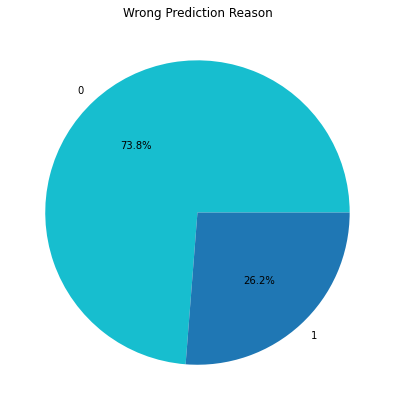

In [7]:
target_1 = predicates[predicates['predicate_wrong_pred']==0].shape[0]
target_2 = predicates[predicates['predicate_wrong_pred']==1].shape[0]
plt.figure(figsize=(15, 7))
plt.pie([target_1,target_2], labels = ["0" , "1"],autopct='%1.1f%%',colors = ["#17becf", "#1f77b4"])
plt.title('Wrong Prediction Reason')

In [8]:
predicates.to_csv('predicates.csv')

In [9]:
predicates.sample(n=100).head(40)

,predicate_proba,predicate_wrong_pred
263008,0.0,1.0
401235,0.0,0.0
421853,1.0,0.0
186560,0.0,0.0
80954,0.0,0.0
31376,0.0,0.0
100875,0.0,0.0
230231,0.0,1.0
242175,0.0,0.0
403141,0.0,0.0
